## Ch8. Unsupervised Learning Techniques

각 학습 방식이 한 번의 학습에서 뽑아낼 수 있는 정보량을 케이크에 비유하면, 비지도 학습은 케이크 본체, 지도 학습은 아이싱, 강화학습은 체리에 불과하다.

- 클러스터링: 비슷한 인스턴스끼리 그룹으로 묶는 작업. 데이터 분석, 고객 세분화, 추천 시스템, 검색 엔진, 이미지 분할,
준지도 학습, 차원 축소 등에 활용된다.
- 이상치 탐지: 정상 데이터가 어떤 모습인지 학습한 후 비정상(이상치)을 탐지.
- 밀도 추정: 데이터를 생성한 확률 과정의 확률밀도함수PDF를 추정하는 작업.

#### k-means 클러스터링
빠르고 효율적으로 클러스터를 찾는 간단한 알고리즘이다. 보통 몇 번의 반복만으로 수렴한다.
- 하드 클러스터링: 각 인스턴스를 단일 클러스터(그룹)에 확정적으로 할당
- 소프트 클러스터링 클러스터별 점수를 부여

중심점(centroid)을 알면 각 인스턴스를 가장 가까운 중심점에 배정해서 쉽게 레이블링 가능(여기서 레이블은 정답이 아니라, 클러스터의 인덱스)
레이블을 알면 각 클러스터의 평균을 구해서 쉽게 중심점을 찾을 수 있다
하지만 처음엔 둘 다 모르기 때문에 먼저 중심점을 무작위로 배치(초기화)하고, 레이블 할당,
중심점 갱신, 반복으로 해결한다.

각 단계마다 인스턴스와 가장 가까운 중심점 사이의 평균 제곱 거리가 절대 증가하지 않고 감소만 하기때문에
결국 유한한 단계 안에 반드시 수렴이 보장한다. 다만, 최적의 해로 수렴한다는 보장은 없다. 로컬 최적해에 갇힐 수 있다.

In [2]:
# KMeans

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=5, random_state=42)
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)
print(y_pred)
print(y_pred is kmeans.labels_)
print(kmeans.cluster_centers_)

[4 1 4 ... 0 4 2]
True
[[-6.92958209 -6.79739545]
 [-2.52846663  9.01204984]
 [ 2.03822483  4.16889545]
 [-8.85754411  7.33176566]
 [ 4.75665206  2.01872582]]


In [4]:
import numpy as np
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
print(kmeans.predict(X_new)) # 새로운 데이터셋에 적용

print(kmeans.transform(X_new).round(2))

[2 4 2 2]
[[11.2   7.45  2.98 10.34  4.76]
 [13.27  8.93  2.37 13.    1.76]
 [10.56  6.03  5.17  7.29  7.82]
 [10.09  6.53  5.31  7.59  7.77]]


#### 중심점 초기화 방법
1. 직접 중심점 위치를 지정하는 방법
이미 중심점 위치를 대략 알고 있다면, 직접 지정 가능하다.

2. 여러 번 무작위 시도 후 최선의 결과 선택
관성을 기준으로 가장 좋은 결과를 판단한다.
- 관성: 각 인스턴스와 그에 가장 가까운 중심점 사이의 거리 제곱을 모두 더한 값, 작을수록 좋다.

3. k-means++
무작위로 첫 번째 중심점을 선택하고 다음 중심점은 이미 선택된 중심점들로부터 멀리 떨어진 인스턴스일수록
선택될 확률이 높게 설정한다. k개의 중심점이 모두 선택될 때까지 반복한다.
sklearn에서 init파라미터의 default.

In [ ]:
# 방법 1. 직접 중심점 위치를 지정하는 방법

good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)
kmeans.fit(X)

print(kmeans.inertia_) # 관성
print(kmeans.score(X)) # 관성과 부호만 반대

12071.114231775138
-12071.114231775135


#### 가속화된 k-means와 미니배치 k-means
- Elkdan의 가속화 알고리즘
삼각 부등식을 활용하여 클러스터가 많은 대규모 데이터셋에서 불필요한 거리 계산을 줄여서 속도를 높인다.
항상 빨라지는 건 아니고, 데이터셋에 따라 오히려 훈련이 느려질 수 있다.

- 미니배치 k-means
매 반복마다 전체 데이터셋을 사용하지 않고, 미니배치만 사용한다.
각 단계마다 중심점을 아주 조금씩만 이동시킨다.

In [7]:
# 미니배치 k-means

from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",42
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


#### 최적의 클러스터 개수 찾기
1. 엘보우 기법
k에 따른 관성을 그래프로 보면, 어느 지점까지는 급격히 떨어지다가 그 이후로는 완만해지는 엘보무 곡선이 나타난다.
이 엘보우 지점을 최적의 k로 추정한다. 대략적인 방법이라는 단점이 있다.

2. 실루엣 점수
##### 실루엣 계수: (b - a) / max(a, b)
- a=같은 클러스터 내 다른 인스턴스들까지의 평균 거리
- b=가장 가까운 다른 클러스터까지의 평균 거리
더 정밀한 방법이지만, 연산 비용이 더 높다.

3. 실루엣 다이어그램
모든 인스턴스의 실루엣 계수를, 클러스터별로 묶고 계수 값 순으로 정렬해서 시각화한다.
가장 풍부한 정보를 가진다.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_) # 실루엣 점수, 1에 가까울수록 좋은 클러스터링

0.4633249646125578

#### k-means의 한계

- 로컬 최적해를 피하기 위해 여러 번 반복 실행해야 하고, 클러스터 개수(k)를 미리 지정해야 한다.
- 클러스터 크기나, 밀도가 서로 다르거나, 클러스터가 구형이 아닌 모양일 때 잘 작동하지 않는다.
예를 들어, 타원형 클러스터에서는 가우시안 혼합 모델이 훨씬 더 잘 작동한다.
- k-means를 실행하기 전 반드시 입력 특성을 스케일링해야 한다.

#### 클러스터링을 이용한 이미지 분할
이미지 분할: 이미지를 여러 개의 영역으로 나누는 작업
- 색상 분할: 비슷한 색상의 픽셀끼리 같은 영역으로 묶음
- 의미론적 분할: 같은 종류의 객체에 속한 픽셀을 모두 같은 영역으로 묶음
- 인스턴스 분할: 같은 종류라도 개체별로 구분해서 영역을 나눔

In [ ]:
# 이미지 불러오기
import PIL
image = np.asarray(PIL.Image.open(filepath))
print(image.shape)
# 색상 분할
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

#### 클러스터링을 이용한 준지도 학습

레이블이 없는 데이터는 많고, 레이블이 있는 데이터는 극히 적은 상황에서, 클러스터링을 활용하면,
어떤 인스턴스를 레이블링할지 선택하는 데 도움이 되고, 각 클러스터 내 가장 흔한 레이블을 나머지 인스턴스로 전파할 수 있다.

In [9]:
# digits 데이터셋(8x8 흑백 숫자이미지)
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [10]:
# 무작위 50개 레이블만 사용
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

print(log_reg.score(X_test, y_test))

0.7581863979848866


In [ ]:
# 대표 이미지 선택 - 클러스터 활용
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

y_representative_digits = np.array([...])

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

In [ ]:
# 레이블 전파

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
print(log_reg.score(X_test, y_test))

y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
	y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
print(log_reg.score(X_test, y_test))

In [ ]:
# 이상치 제거

percentile_closet = 50

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
	in_cluster = (kmeans.labels_ == i)
	cluster_dist = X_cluster_dist[in_cluster]
	cutoff_distance = np.percentile(cluster_dist, percentile_closet)
	above_cutoff = (X_cluster_dist > cutoff_distance)
	X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
print(log_reg.score(X_test, y_test))

print((y_train_partially_propagated == y_train[partially_propagated]).mean())

#### Active Learning

클러스터링 기반 레이블링 다음 단계로 이어지는 과정이고, 모델이 스스로 부족한 부분을 파악해서 추가로 어떤 인스턴스를
레이블링해야 할지 알려주는, 반복적이고 진화하는 과정이다.

#### DBSCAN

밀도 기반 클러스터링 알고리즘으로, 클러스터를 밀도가 높은 연속적인 영역으로 정의한다.
클러스터들이 저밀도 영역으로 잘 분리되어 있을 때 효과적이다.

매우 간단하지만 강력하고, 임의의 개수, 임의의 모양을 가진 클러스터를 식별가능하고,
이상치에 강건하다.
클러스터마다 밀도 차이가 크면 제대로 못 잡아낼 수 있고, 일부 클러스터 주변에 충분히 낮은 밀도의
영역이 없으면 클러스터 구분이 잘 안되고, 계산복잡도가 O(m^2n)으로 높다.

In [12]:
# DBSCAN

from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

print(dbscan.labels_) # -1로 표시된 인스턴스는 이상치로 판단한 것
print(dbscan.core_sample_indices_) # 핵심 인스턴스들의 인덱스
print(dbscan.components_) # 핵심 인스턴스 자체의 좌표값

[ 0  2 -1 -1  1  0  0  0  2  5  2  3  0  2  2  2  4  2  2  4  0  5  1  0
  5  5  3  2  2  2  4  5  0  6  1 -1  0  0  2  3 -1  3  4 -1  4  4  2  0
  6  2  0  2  4  0  3  3  0  3  5  2 -1  3  0  5  0  0  0  2  3  0  3  6
  0  2  4  4  0  3  0  4  0  3 -1  3  4  0 -1  2  2  4  1  6  0  5  2  6
  2  3  3 -1  2 -1  2  4  0  0  0  2  5  2  0  2 -1  2  3  1  5  2  0  4
  2  1  2  4  4  0  0  6  2  2  0  2 -1  2  0  3  3  5 -1  3  3  5  2  4
  2  2  2  4  2  4  0 -1  2  1  2  6  4  2  3  2 -1  2  0  0  2  0  4  0
  4  4  1  6  3  2  6  1  4  4  2  0  6  0  1  0  2  5  1  1  2  2  2  2
  0  5  5  1  4  5  0  3  3  0  0  0  2  0  5  2 -1  2  3  5  2  2  0  4
  0  4  2  2  4  2  2  3  2  3  0  1  2  0  4 -1  6  0  3  3  5 -1  5  4
  3  5  0  2 -1  3  6  3  3  4  3  2  2  2  1  4  0  2  2 -1  2  6  3  4
  4  2  2  1  0  1  6  3  2  4  0  3  5  0  3  2  0  2  5  4  5  2 -1  6
  5  2  2  2  0  6  1  6  2  1  3  5  0  1 -1  1  2  2  4 -1  2  0  0  0
  0  2  6  6 -1  1  2  5  3  5  4  0  2  0 -1  6  2

In [13]:
# DBSCAN에 predict()메서드가 없기 때문에, KNN 분류기 별도 학습을 통해, 새로운 인스턴스가 어느 클러스터에 속하는지 예측 가능하도록 한다.

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
print(knn.predict(X_new))
print(knn.predict_proba(X_new))

[6 0 3 2]
[[0.24 0.   0.   0.   0.   0.   0.76]
 [1.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.3  0.7  0.   0.   0.  ]
 [0.   0.   1.   0.   0.   0.   0.  ]]


In [ ]:
# 이상치 판별 로직

y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  3, -1])

#### 기타 클러스터링 알고리즘

1. 응집형 클러스터링
아래에서 위로 클러스터 계층을 쌓아 올린다.

2. BIRCH
매우 큰 데이터셋 전용으로 설계된 알고리즘으로 학습 중에 트리 구조를 만들어서,
모든 인스턴스를 트리에 저장하지 않고도 새 인스턴스를 빠르게 클러스터에 할당한다.

3. 평균 이동
각 원 안에 있는 인스턴스들의 평균 위치를 계산해서 원의 중심을 그 평균 위치로 더 이상 움직이지 않을 때까지 이동한다.

4. 유사도 전파
인스턴스들이 서로 메시지를 주고받으며, 모든 인스턴스가 자신을 대표할 다른 인스턴스를 선출해서 그를 선출한 모든 인스턴스가 하나의 클러스터를 형성한다.

5. 스펙트럴 클러스터링
인스턴스 간 유사도 행렬을 입력받아 저차원 임베딩 생성하고(행렬 차원 축소), 저차원에서 다른 클러스터링 알고리즘을 적용한다.

#### 가우시안 혼합 모델

데이터가 여러 개의 가우시안 분포(정규분포)가 섞인 형태로부터 생성됐다고 가정하는 확률 모델이다. 각 가우시안 분포에서 생성된 인스턴스들의
집합이 하나의 클러스터를 형성하며, 보통 타원체 모양을 띠고, 각 클러스터마다 모양,크기,밀도,방향이 다를 수 있다.

클러스터 파라미터 무작위 초기화 후, 기댓값 단계에서 각 인스턴스가 각 클러스터에 속할 확률을 추정하고, 최대화 단계에서
각 인스턴스를 속할 확률로 가중치를 줘서  클러스터 파라미터를 갱신한다. 수렴할 때까지 기댓값 단계와 최대화 단계를 묶어서 반복한다.

In [15]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

print(gm.weights_)
print(gm.means_)
print(gm.covariances_)
print(gm.converged_)
print(gm.n_iter_)
print(gm.predict(X))
print(gm.predict_proba(X).round(3))

X_new, y_new = gm.sample(6)
print(X_new)
print(y_new)
print(gm.score_samples(X).round(2))

[0.58665595 0.21043353 0.20291052]
[[ 0.49067581  0.2579044 ]
 [ 1.72666283 -0.07241745]
 [-0.74886394  0.5549146 ]]
[[[ 0.1633683  -0.09679743]
  [-0.09679743  0.28719319]]

 [[ 0.06282163  0.06680095]
  [ 0.06680095  0.08831191]]

 [[ 0.05311309  0.06174985]
  [ 0.06174985  0.08971553]]]
True
15
[0 0 0 0 2 0 0 0 1 0 1 0 0 1 1 1 0 1 0 2 0 0 2 0 0 0 0 1 1 1 2 0 0 2 2 0 0
 0 1 0 2 0 2 1 2 0 1 0 2 1 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 2 0 0
 0 0 0 0 0 2 0 0 0 0 2 0 1 0 0 2 2 2 0 0 0 2 0 0 0 1 0 2 1 0 0 0 0 1 0 1 0
 1 1 1 0 2 0 1 0 0 1 2 0 0 0 0 0 2 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 2 1 1 1 0
 1 2 0 0 1 2 1 2 2 0 0 1 0 0 0 0 1 0 2 0 2 2 2 2 0 1 2 2 0 0 1 0 2 0 2 0 1
 0 2 2 1 0 1 1 0 0 0 2 2 0 0 0 0 0 0 0 1 0 0 1 2 1 0 0 1 1 0 2 0 0 1 0 2 0
 1 0 1 0 0 2 1 0 2 1 2 0 0 0 0 1 0 2 0 0 0 1 2 0 2 0 0 0 0 1 0 1 2 2 0 1 1
 0 0 2 0 0 2 1 1 2 0 2 2 0 1 0 0 0 0 0 0 1 0 1 0 2 0 0 2 2 0 1 1 0 0 2 2 2
 1 2 0 0 0 2 2 2 0 1 2 0 1 0 0 0 0 0 2 2 0 2 0 0 0 0 2 0 1 0 2 2 0 0 0 0 0
 0 0 2 0 0 1 0 2 2 0 0 2 2

#### 가우시안 혼합 모델을 이용한 이상치 탐지

밀도가 낮은 영역에 위치한 인스턴스를 이상치로 간주한다. 기준은 threshold를 통해 정한다.

In [16]:
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

#### 클러스터 개수 선택하기

GMM에서는 inertia나 실루엣 점수같은 지표들을 신뢰할 수 없기 때문에 대안으로 정보 기준을 사용한다.

- BIC(베이즈 정보 기준)
##### BIC=log(m)⋅p−2log(L^)

- AIC(아카이케 정보 기준)
##### AIC=2p−2log(L^)

BIC가 선택하는 모델이 AIC보다 더 단순한 경향이 있다.
대신 BIC로 선택된 모델은 데이터에 덜 딱 들어맞는 경향이 있다.(과소적합 리스크)

#### 우도 함수
확률과 우도의 차이
- 확률: x의 함수, 파라미터 θ를 알고 있을 때, 미래 결과 x가 얼마나 그럴듯한지를 의미한다.
- 우도: θ의 함수, 결과 x를 이미 관츨했을 때, 특정 파라미터 값 θ가 얼마나 그럴듯한지를 의미한다.

우도 함수는 확률분포가 아니다. 확률분포는 모든 x에 대해 적분하면 항상 1이지만,
우도 함수는 모든 θ에 대해 적분해도 1이 된다는 보장이 없다.

- MLE(최대우도추정)
데이터셋 X가 주어졌을 때, 우도 함수를 최대화하는 θ값을 찾는 작업

- MAP(최대사후추정)
θ에 대한 사전확률분포 g(θ)가 있다면, 단순히 L(θ|x)만 최대화하는 게 아니라
L(θ|x)g(θ)를 최대화

실무적으로는 계산 이점의 이유로 로그우도를 쓴다.

In [17]:
print(gm.bic(X)) # BIC
print(gm.aic(X)) # AIC

2808.285587199892
2724.8537474571954


#### 베이지안 가우시안 혼합 모델

최적의 클러스터 개수 k를 찾기 위해 여러 k로 반복 학습하고 BIC/AIC 비교하는 수동적인 탐색 과정을 자동화한다.
불필요한 클러스터의 가중치를 자동으로 0으로 만들어주는 알고리즘이다.
스스로 필요 없는 클러스터를 걸러낸다.

In [19]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, max_iter=500,
							  random_state=42)
bgm.fit(X)
print(bgm.weights_.round(2))

[0.07 0.15 0.13 0.12 0.14 0.16 0.   0.11 0.11 0.  ]


#### 이상치/신규성 탐지를 위한 기타 알고리즘

1. Fast-MCD(최소 공분산 행렬식)
정상 인스턴스가 단일 가우시안 분포에서 생성됐다고 가정하고, 데이터셋에 정상 분포에서 나오지 않은 이상치가 섞여있다고 가정한다.

2. Isolation Forest(고립 포레스트)
고차원 데이터셋에서 특히 효율적인 이상치 탐지 알고리즘이다.
무작위 분할로 고립시키고, 적은 분할은 이상치로 본다.

3. LOF(지역 이상치 인자)
이상치 탐지에 좋은 알고리즘으로, 어떤 인스턴스 주변의 밀도를, 그 인스턴스의 이웃들 주변 밀도와 비교한다.

4. One-Class SVM(단일 클래스 SVM)
신규성 탐지에 적합하다. 고차원 데이터셋에 특히 강하지만, 대규모 데이터셋에서는 확장성이 떨어진다.
원점으로부터 분리하는 경계를 찾는다.

5. PCA
정상 인스턴스와 이상치의 재구성 오차를 비교한다.
꽤 효율적인 이상치 탐지 접근법이다.

#### Exercises

1. 클러스터링의 정의와 몇 가지 예
-> 레이블이 없는 데이터에서, 서로 비슷한 인스턴스들을 자동으로 찾아서 그룹으로 묶는 비지도 학습이다.
대표 알고리즘은 k-means, DBSCAN, 가우시안 혼합모델(GMM), 응집형 클러스터링 등이 있다.

2. 클러스터링 알고리즘의 주요 응용 분야
-> 고객 세분화, 데이터 분석, 차원 축소, 피쳐 엔지니어링, 이상치 탐지, 준지도 학습, 검색 엔진, 이미지 분할 등

3. k-평균 알고리즘을 사용할 때 적절한 클러스터 개수를 선택하는 두 가지 기법
-> 관성을 활용한 엘보우 기법과 더 정밀한 방법인 실루엣 점수

4. 레이블 전파란? 왜 구현해야 하며, 어떻게 구현하나?
-> 클러스터링을 통해 얻은 소수의 레이블을 같은 클러스터에 속한 나머지 모든 인스턴스에 그대로 전파시키는 기법이다.
레이블 있는 데이터는 적고, 레이블 없는 데이터는 많은 상황이 많기 때문에 레이블 전파를 구현해야 한다.
클러스터링을 수행하고, 각 클러스터의 대표 이미지를 찾고, 대표 이미지들을 사람이 직접 보고 레이블링 후, 대표 레이블을
같은 클러스터의 모든 인스턴스에 적용하는 레이블 전파를 하고, 클러스터 중심에서 먼 인스턴스(이상치)를 제거하고,
전파된 레이블로 모델을 학습한다.

5. 대규모 데이터셋에 적용 가능한 클러스터링 알고리즘 두 가지와, 고밀도 영역을 찾는 알고리즘 두 가지
-> 대규모: 미니배치 k-means, BIRCH / 고밀도: DBSCAN, 평균 이동

6. 능동 학습이 유용하게 활용될 수 있는 사례를 생각해 볼 수 있나? 어떻게 구현할 수 있을까?
->  의료 영상 진단, 금융 사기 탐지, 콜센터/고객 문의 자동 분류, 자율주행 데이터 라벨링 등에 유용하게 활용될 수 있고,
초기 소량 레이블 데이터로 모델 학습하고, 레이블 없는 데이터에 예측 수행하고, 가장 불확실한 인스턴스 N개 선정하고,
사람에게 레이블을 요청하고, 훈련 데이터에 추가해서 재학습한다.

7. 이상치 탐지와 신규성 탐지의 차이점
-> 훈련 데이터에 대한 가정이 핵심 차이다. 이상치 탐지는 훈련 데이터에 이상치가 섞여 있을 수 있다고 가정하고,
신규성 탐지는 훈련 데이터가 이상치가 전혀 없다고 가정한다.

8. 가우시안 혼합 모델이란? 어떤 작업에 사용할 수 있나?
-> 데이터가 여러 개의 가우시안 분포(정규분포)가 섞여서 생성됐다고 가정하는 확률 기반 모델이다.
클러스터링, 밀도 추정, 이상치 탐지, 데이터 생성 등에 사용할 수 있다.

9. 가우시안 혼합 모델을 사용할 때, 클러스터 개수를 찾는 두 가지 기법
-> BIC(베이즈 정보 기준)와 AIC(아카이케 정보 기준)

87


c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\lbjic\AppData\Local\Programs\Python\Python312\Lib\site-package

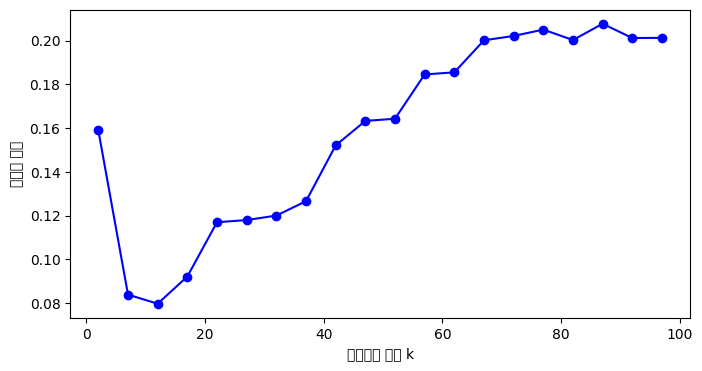

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",87
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


: 

In [ ]:
# Exercises 10. Olivetti Faces

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# 데이터 로드
olivetti = fetch_olivetti_faces()
X = olivetti.data
y = olivetti.target

# 훈련/검증/테스트셋 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# k-means로 최적 클러스터 개수 탐색(실루엣 점수)
k_range = range(2, 100 ,5)
silhouette_scores = []

for k in k_range:
	km = KMeans(n_clusters=k, random_state=42, n_init=10)
	labels = km.fit_predict(X_train)
	score = silhouette_score(X_train, labels)
	silhouette_scores.append(score)

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(best_k)

plt.figure(figsize=(8,4))
plt.plot(list(k_range), silhouette_scores, "bo-")
plt.xlabel("클러스터 개수 k")
plt.ylabel("실루엣 점수")
plt.show()

# 최적 k로 최적 k-means 학습
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_train)

In [3]:
# Exercise 11. k-means를 차원 축소 도구로 활용하기

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import numpy as np

# 데이터 로드
olivetti = fetch_olivetti_faces()
X = olivetti.data
y = olivetti.target

# 훈련/검증/테스트셋 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# 베이스라인 분류기(비교 대상)
clf_baseline = RandomForestClassifier(random_state=42)
clf_baseline.fit(X_train, y_train)
baseline_acc = clf_baseline.score(X_val, y_val)
print(baseline_acc)

# k-means로 차원 축소한 특성만으로 분류기 학습 - transform()으로 차원 축소
k_range = range(5, 200, 5)
reduced_accuracies = []

for k in k_range:
	kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
	X_train_reduced = kmeans.fit_transform(X_train)
	X_val_reduced = kmeans.transform(X_val)

	clf = RandomForestClassifier(random_state=42)
	clf.fit(X_train_reduced, y_train)
	acc = clf.score(X_val_reduced, y_val)
	reduced_accuracies.append(acc)

best_k_reduced = list(k_range)[np.argmax(reduced_accuracies)]
best_acc_reduced = max(reduced_accuracies)
print(f'k={best_k_reduced}, best_acc_reduced={best_acc_reduced}')

# 원본 특성+축소 특성으로 학습
combined_accuracies = []

for k in k_range:
	kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
	X_train_reduced = kmeans.fit_transform(X_train)
	X_val_reduced = kmeans.transform(X_val)

	X_train_combined = np.hstack([X_train, X_train_reduced])
	x_val_combined = np.hstack([X_val, X_val_reduced])

	clf = RandomForestClassifier(random_state=42)
	clf.fit(X_train_combined, y_train)
	acc = clf.score(x_val_combined, y_val)
	combined_accuracies.append(acc)

best_k_combined = list(k_range)[np.argmax(combined_accuracies)]
best_acc_combined = max(combined_accuracies)
print(f'k={best_k_combined}, best_acc_combined={best_acc_combined}')

# 최종 비교
print(f'베이스라인: {baseline_acc}'
      f'차원 축소: {best_acc_reduced}'
	  f'원본 + 축소 결합: {best_acc_combined}')

0.925
k=195, best_acc_reduced=0.875
k=20, best_acc_combined=0.95
베이스라인: 0.925차원 축소: 0.875원본 + 축소 결합: 0.95


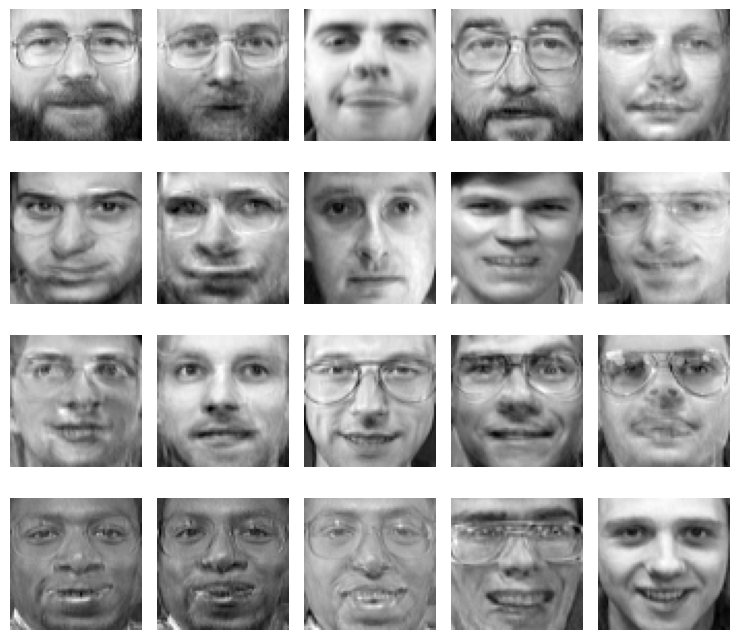

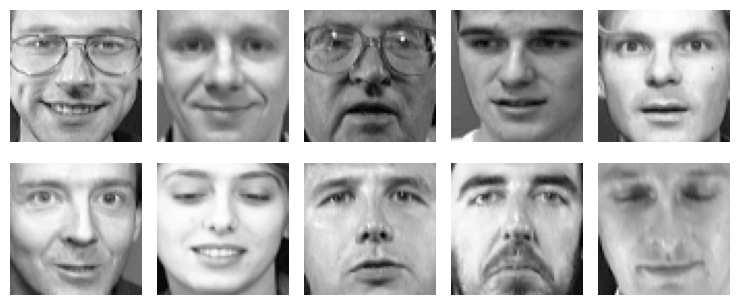

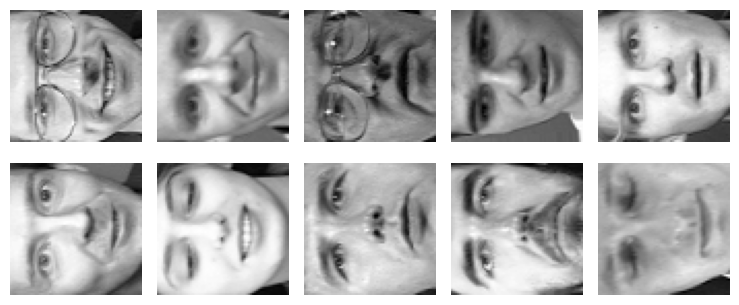

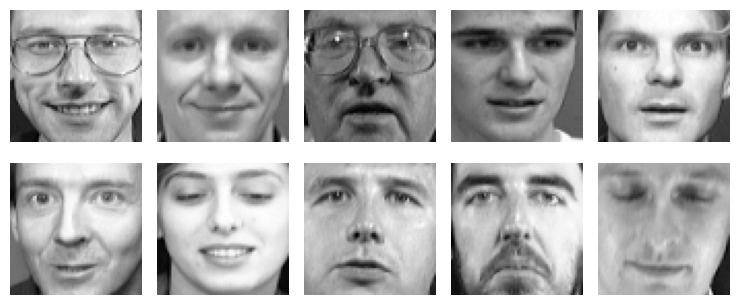

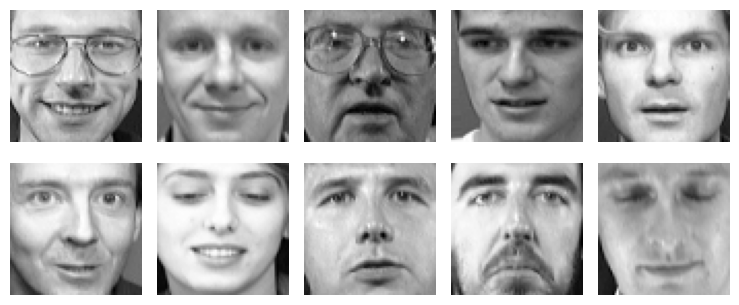

정상 이미지 평균 점수:     -5515150.5
회전된 이미지 평균 점수:   -38698308.0
반전된 이미지 평균 점수:   -16354133.0
어둡게 한 이미지 평균 점수: -101666048.0


In [6]:
# Exercises 12. GVM으로 얼굴 생성 및 이상치 탐지

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy.ndimage import rotate

# 데이터 로드
olivetti = fetch_olivetti_faces()
X = olivetti.data
y = olivetti.target

# 훈련/검증/테스트셋 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# PCA로 차원 축소
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# GMM 학습
gm = GaussianMixture(n_components=40, random_state=42)
gm.fit(X_train_pca)

# 새로운 얼굴 생성
n_faces_to_generate = 20
X_generated_pca, y_generated = gm.sample(n_samples=n_faces_to_generate)

# 복원
X_generated = pca.inverse_transform(X_generated_pca)

def plot_faces(faces,  n_cols=5):
	n_rows = (len(faces) - 1) // n_cols + 1
	plt.figure(figsize=(n_cols * 1.5, n_rows * 1.7))
	for i, face in enumerate(faces):
		plt.subplot(n_rows, n_cols, i + 1)
		plt.imshow(face.reshape(64, 64), cmap="gray")
		plt.axis("off")
	plt.tight_layout()
	plt.show()

plot_faces(X_generated)

# 이미지 변형 후 이상치 탐지
def rotate_faces(faces, angle=90):
	rotated = []
	for face in faces:
		img = face.reshape(64, 64)
		rotated_img = rotate(img, angle, reshape=False, mode="constant")
		rotated.append(rotated_img.reshape(-1))
	return np.array(rotated)

def flip_faces(faces):
	flipped = []
	for face in faces:
		img = face.reshape(64, 64)
		flipped_img = np.fliplr(img)
		flipped.append(flipped_img.reshape(-1))
	return np.array(flipped)

def darken_faces(faces, factor=0.3):
	return faces * factor

n_samples = 10
X_normal = X_val[:n_samples]
X_rotated = rotate_faces(X_normal, angle=90)
X_flipped = flip_faces(X_normal)
X_darkened = darken_faces(X_normal)

plot_faces(X_normal) # 정상
plot_faces(X_rotated) # 회전
plot_faces(X_flipped) # 반전
plot_faces(X_darkened) # 어두움

X_normal_pca = pca.transform(X_normal)
X_rotated_pca = pca.transform(X_rotated)
X_flipped_pca = pca.transform(X_flipped)
X_darkened_pca = pca.transform(X_darkened)

normal_scores = gm.score_samples(X_normal_pca)
rotated_scores = gm.score_samples(X_rotated_pca)
flipped_scores = gm.score_samples(X_flipped_pca)
darkened_scores = gm.score_samples(X_darkened_pca)
print(f"정상 이미지 평균 점수:     {normal_scores.mean()}")
print(f"회전된 이미지 평균 점수:   {rotated_scores.mean()}")
print(f"반전된 이미지 평균 점수:   {flipped_scores.mean()}")
print(f"어둡게 한 이미지 평균 점수: {darkened_scores.mean()}")

In [7]:
# Exercises 13. PCA 재구성 오차를 이용한 이상치 탐지

# 데이터 로드
olivetti = fetch_olivetti_faces()
X = olivetti.data
y = olivetti.target

# 훈련/검증/테스트셋 분할
X_train_val, X_test, y_train_val, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# PCA로 차원 축소
pca = PCA(n_components=0.99, random_state=42)
X_train_pca = pca.fit_transform(X_train)

# 재구성 오차 계산 함수
def reconstruction_error(X, pca_model):
	X_reduced = pca_model.transform(X)
	X_reconstructed = pca_model.inverse_transform(X_reduced) # 복원
	mse = np.mean((X - X_reconstructed) ** 2, axis=1)
	return mse, X_reconstructed

# 정상 이미지의 재구성 오차
n_samples = 10
X_normal = X_val[:n_samples]
normal_errors, X_normal_reconstructed = reconstruction_error(X_normal, pca)

# 이상치 이미지 생성은 이전 문제 함수 재사용
X_rotated = rotate_faces(X_normal, angle=90)
X_flipped = flip_faces(X_normal)
X_darkened = darken_faces(X_normal)

rotated_errors, X_rotated_reconstructed = reconstruction_error(X_rotated, pca)
flipped_errors, X_flipped_reconstructed = reconstruction_error(X_flipped, pca)
darkened_errors, X_darkened_reconstructed = reconstruction_error(X_darkened, pca)

# 재구성 오차 비교
print(f"정상 이미지 평균 오차: {normal_errors.mean()}")
print(f"회전된 이미지 평균 오차: {rotated_errors.mean()}")
print(f"반전된 이미지 평균 오차: {flipped_errors.mean()}")
print(f"어둡게 한 이미지 평균 오차: {darkened_errors.mean()}")

정상 이미지 평균 오차: 0.0019205569988116622
회전된 이미지 평균 오차: 0.007937624119222164
반전된 이미지 평균 오차: 0.0027767117135226727
어둡게 한 이미지 평균 오차: 0.001060923095792532


## Ch9. Introduction to Artificial Neural Networks

지능적인 기계를 만들기 위해 뇌의 구조에서 영감을 얻은 것이 바로 인공 신경망의 시작이다.
인공 신경망(ANN)은 우리 뇌의 생물학적 뉴런 네트워크에서 영감을 받은 머신러닝 모델이고, 딥러닝의 가장 핵심적인 토대이다.

#### 생물학적 뉴런에서 인공 뉴런으로: ANN의 역사

신경생리학자 워론 매컬록과 수학자 월터 피츠가 최초로 논문 "A Logical Calculus of Ideas Immanent in Nervous Activity"에서,
동물 뇌 속 생물학적 뉴런들이 명제 논리를 이용해 복잡한 계산을 수행하는 방식을 단순화한 계산 모델로 ANN을 제안했다.

ANN에 대한 낙관적인 기대와 비관적인 흐름이 반복되다가 현재는 다시 한 번 관심의 흐름이 일어나고 있다.
이제는 방대한 데이터, 컴퓨팅 파워의 급증, 훈련 알고리즘의 개선, 이론적 한계들이 실전에서는 무해,
트랜스포머 아키텍처의 발명, 선순환 구조 등의 요인로 이번의 흐름은 지속적으로 이어질 것으로 보인다.

#### 생물학적 뉴런

**구성 요소**
- 세포체: 핵과 세포의 복잡한 구성 요소 대부분을 담고 있음
- 수상돌기: 가지처럼 뻗어나간 여러 개의 확장부, 다른 뉴런으로부터 신호를 받는 역할
- 축삭: 하나의 매우 긴 확장부
- 종말가지: 축삭 끝부분에서 여러 갈래로 갈라진 가지들
- 시냅스 말단: 종말가지 끝에 있는 아주 작은 구조, 다른 뉴런의 수상돌기나 세포체와 연결됨

생물학적 뉴런은 활동 전위(짧은 전기 자극)를 만들어내고, 이 신호가 축삭을 따라 이동하면서,
시냅스가 신경전달물질을 방출하고, 뉴런이 몇 밀리초 안에 충분한 양의 신경전달물질을 받으면 자신도 전기 자극을 발화한다.

개별 뉴런 하나하나는 비교적 단순하게 행동하는 것처럼 보이지만, 이런 단순한 뉴런들의 네트워크가 모여서 매우 복잡한 계산을 수행할 수 있다.

**생물학적 신경망(BNN)의 구조**
뇌의 일부 영역은 이미 지도화 되어있다.
특히 대뇌 피질에는 뉴런들이 종종 연속된 여러 층으로 조직화되어 있음이 밝혀졌다.

#### 뉴런을 이용한 논리 연산

- 초기 인공 뉴런 모델: 하나 이상의 이진 입력과 하나의 이진 출력을 가진다.
입력 중 일정 개수 이상이 활성화되면 출력이 활성화된다.

**네 가지 논리 연산 네트워크**
1. 항등 함수: 뉴런 A가 활성화되면 C도 활성화되고, A가 꺼져있으면 C도 꺼진다.
A의 상태를 그대로 C가 따라간다.

2. 논리 AND: C는 A와 B가 둘 다 활성화됐을 때만 활성화된다.

3. 논리 OR: C는 A 또는 B 둘 중 하나라도 활성화되면 활성화된다.

4. 억제 연결이 있는 경우: 생물학적 뉴런처럼, 어떤 입력 연결이 뉴런의 활동을 억제할 수 있다고 가정한다.
이 경우 C는 A가 활성화되어있고, B가 꺼져있을 때만 활성화된다.

이런 단순한 네트워크들을 조합하면, 훨씬 복잡한 논리 표현식도 계산할 수 있다.

#### 퍼셉트론

1957년 프랭크 로젠블랫이 발명한 가장 단순한 ANN 아키텍처 중 하나. 임계 논리 유닛(TLU) 또는 선형 임계 유닛(LTU)이라는
약간 다른 인공 뉴런을 기반으로 한다.

- TLU: 입력과 출력이 이진값이 아닌 숫자이고, 각 입력 연결마다 가중치가 붙는다.
선형 함수를 계산하고, 그 결과에 계단 함수(step function)를 적용한다.
단일 TLU는 간단한 선형 이진 분류에 사용 가능하다.

**퍼셉트론의 구조**
- 하나 이상의 TLU가 하나의 층에 조직화되고, 모든 TLU가 모든 입력에 연결된다.

행렬 연산으로 한 번에 출력행렬(특정 인스턴스가 특정 뉴런에 대해 활성화됐는지 여부)을 계산할 수 있다.
- Y_hat=ϕ(XW+b)

퍼셉트론은 두 뉴런이 동시에 발화하면 그 사이의 연결 가중치가 강화되는 경향이라는 Hebb의 규칙을 변형하여
예측 오차를 고려해서, 정답 예측에 기여했을 연결을 강화한다.
- 가중치 갱신 공식: w_(i,j)(next step)​=w_(i,j​)+η(y_j​−y_j_hat​)x_i​

각 출력 뉴런의 결정 경계는 선형이라서, 퍼셉트론은 복잡한 패턴을 할 수 없다.
하지만 훈련 인스턴스가 선형적으로 분리 가능하다면, 로젠블랫은 이 알고리즘이  반드시 해로 수렴함을 증명했다.(**퍼셉트론 수렴 정리**)

**로지스틱 회귀 대비 퍼셉트론의 단점**
- 클래스 확률을 출력하지 않는다.
- 기본적으로 규제를 사용하지 않는다.
- 훈련셋에서 예측 오류가 없어지면 바로 학습을 멈추기 때문에, 일반화 성능이 떨어지는 경향이 있다.

다만 훈련 속도는 더 빠를 수 있다.

**결정적 한계**
- 배타적 논리합(XOR)같은 아주 단순한 문제조차 풀 수 없다.

**해결책**
- 여러 개의 퍼셉트론을 층층이 쌓은 다층 퍼셉트론으로 해결할 수 있다는 것이 밝혀졌다.

In [21]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)
print(y_pred)

[ True False]


#### 다층 퍼셉트론(MLP)과 역전파(Backpropagation)

MLP가 위에서 언급한 XOR 문제를 해결할 수 있다.

**MLP의 구조**
- 입력층: 데이터가 들어오는 곳
- 은닉층: 하나 이상 존재, 원래는 TLU로 구성, 입력에 가까운 것은 하위층, 출력에 가까운 것은 상위층
- 출력층: 최종 결과를 내는 마지막 층

신호가 입력->출력 한 방향으로만 흐르기 때문에, 이런 구조를 피드포워드 신경망(FNN)이라고 부른다.

- 심층 신경망(DNN): 은닉층이 깊게 여러 겹 쌓인 ANN, 딥러닝이 연구하는 대상이다.

오랫동안 연구자들은 MLP를 훈련시키는 방법을 찾지 못했고, 1960년대 초, 경사하강법을 신경망 훈련에 쓰자는 논의가 있었지만,
복잡한 모델에서 효율적으로 그라디언트를 계산하는 방법은 몰랐다.
1970년대에 모든 기울기를 자동으로, 효율적으로 계산하는 기법(역방향 자동미분)을 제안했다.
신경망을 순전파 한 번, 역전파 한 번 통과하는 것만으로 모든 파라미터에 대한 오차의 기울기를 계산 가능하다.
이 기울기를 통해 경사하강법 스텝을 수행을 반복해서 오차가 점점 감소한다.

**역방향 자동미분 + 경사하강법 = 역전파**

**역전파의 상세 작동 과정**
1. 미니배치 단위로 처리하고, 전체 훈련셋을 여러 번 통과한다.
2. 순전파: 미니배치에 대해 첫 은닉층부터 출력층까지 순서로 출력 계산. 역전파를 위해 모든 중간 결과를 보존한다.
3. 오차 측정: 손실 함수로 원하는 출력과 실제 출력을 비교
4. 출력층 파라미터의 오차 기여도 계산: 연쇄 법칙을 해석적으로 적용해서 빠르고 정확하게 계산, 파라미터마다 기울기 하나씩 산출
5. 역방향으로 계속 진행: 아래층 각 연결이 오차에 얼마나 기여했는지, 연쇄 법칙을 계속 적용하며 입력층까지 거슬러 올라간다.
6. 경사하강법 스텝: 계산된 기울기를 이용해 모든 연결 가중치와 편향을 조정

주의할 점은 다양성을 위해 가중치 **무작위** 초기화는 필수이다.

MLP를 경사하강법(역전파)로 훈련시키기 위해서 활성화 함수를 계단 함수(평평한 구간만 있어 기울기가 없는 문제) 대신, 로지스틱(시그모이드)함수를 사용한다.

#### sklearn으로 MLP 구축 및 훈련하기

#### 회귀 MLP

In [23]:
# 회귀 MLP, 회귀 MLP의 출력 뉴런 개수 = 예측하려는 타깃의 차원 수

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
	housing.data, housing.target, random_state=42
)
# 은닉층 3개, 각 50개 뉴런
mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50],
					   early_stopping=True, verbose=True, random_state=42)

pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)

print(mlp_reg.best_validation_score_)

y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(rmse)

Iteration 1, loss = 0.85190332
Validation score: 0.534299
Iteration 2, loss = 0.28288639
Validation score: 0.651094
Iteration 3, loss = 0.22884372
Validation score: 0.699782
Iteration 4, loss = 0.20746145
Validation score: 0.720468
Iteration 5, loss = 0.19649383
Validation score: 0.724839
Iteration 6, loss = 0.18928708
Validation score: 0.740084
Iteration 7, loss = 0.18132029
Validation score: 0.747406
Iteration 8, loss = 0.17556450
Validation score: 0.753945
Iteration 9, loss = 0.17190651
Validation score: 0.760500
Iteration 10, loss = 0.16687650
Validation score: 0.759213
Iteration 11, loss = 0.16329479
Validation score: 0.761907
Iteration 12, loss = 0.16054473
Validation score: 0.768950
Iteration 13, loss = 0.15690181
Validation score: 0.762699
Iteration 14, loss = 0.15630644
Validation score: 0.766003
Iteration 15, loss = 0.15712517
Validation score: 0.778464
Iteration 16, loss = 0.15155981
Validation score: 0.774237
Iteration 17, loss = 0.14957641
Validation score: 0.778361
Iterat

**sklearn 신경망의 한계**
GPU 가속을 지원하지 않아서, 신경망 기능도 상당히 제한적이다. -> PyTorch로 전환하는 이유

**회귀 MLP의 전형적인 구조**
- 은닉층 개수: 문제에 따라 다르지만, 보통 1~5개
- 은닉층당 뉴런 수: 문제에 따라 다르지만, 보통 10~100개
- 출력 뉴런 수: 타깃 차원당 1개
- 은닉층 활성화 함수: ReLU
- 출력층 활성화 함수: 없음, 또는 ReLU/softplus(양수 출력 시), sigmoid/tanh(범위 제한 시)
- 손실 함수: MSE, 이상치 있으면 Huber

#### 분류 MLP

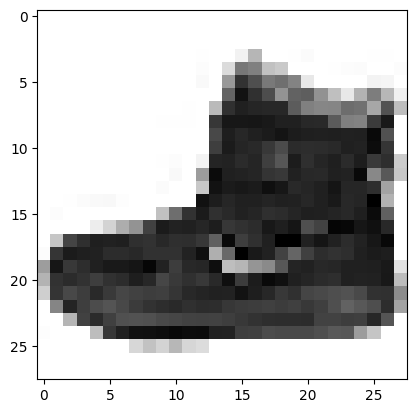

Ankle boot


In [24]:
# 분류 MLP

from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt

fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)
targets = fashion_mnist.target.astype(int)

X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]

X_sample = X_train[0].reshape(28, 28)
plt.imshow(X_sample, cmap="binary")
plt.show()

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
			   "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print(class_names[y_train[0]])

In [25]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

mlp_clf = MLPClassifier(hidden_layer_sizes=[300, 100], verbose=True, early_stopping=True,
						random_state=42)
pipeline = make_pipeline(MinMaxScaler(), mlp_clf)
pipeline.fit(X_train, y_train)
accuracy = pipeline.score(X_test, y_test)

X_new = X_test[:15]
print(mlp_clf.predict(X_new))

y_proba = mlp_clf.predict_proba(X_new)
print(y_proba[12])

Iteration 1, loss = 0.55394420
Validation score: 0.854833
Iteration 2, loss = 0.39017365
Validation score: 0.867500
Iteration 3, loss = 0.34572472
Validation score: 0.877500
Iteration 4, loss = 0.31541926
Validation score: 0.881167
Iteration 5, loss = 0.29351007
Validation score: 0.887167
Iteration 6, loss = 0.28459028
Validation score: 0.889167
Iteration 7, loss = 0.26775210
Validation score: 0.885500
Iteration 8, loss = 0.25610516
Validation score: 0.886667
Iteration 9, loss = 0.24488907
Validation score: 0.893167
Iteration 10, loss = 0.23915583
Validation score: 0.888500
Iteration 11, loss = 0.22290961
Validation score: 0.897167
Iteration 12, loss = 0.21925185
Validation score: 0.889667
Iteration 13, loss = 0.21249406
Validation score: 0.892167
Iteration 14, loss = 0.20374069
Validation score: 0.891333
Iteration 15, loss = 0.19557455
Validation score: 0.893833
Iteration 16, loss = 0.19099949
Validation score: 0.893667
Iteration 17, loss = 0.18445775
Validation score: 0.890333
Iterat

#### 하이퍼파라미터 튜닝 가이드라인

신경망은 너무 많은 하이퍼파라미터를 조정할 수 있다는 점이 유연성이자 단점이다.

- 은닉층 개수: 많은 문제에서, 은닉층 1개로 시작해도 꽤 괜찮은 결과를 얻을 수 있다.
이론적으로, 은닉층 1개짜리 MLP도 뉴런 수만 충분하면 아무리 복잡한 함수든 모델링 가능하다.
하지만 파라미터 효율성 면에서는 깊은 신경망이 훨씬 우수하다. 층층이 특성을 재사용하고 조합할 수 있다는 게 핵심 장점이다.
복잡한 문제에서는 훈련셋에 과적합이 시작될 때까지 개수를 점차 늘려나간다.

- 은닉층당 뉴런 수: 입력층과 출력층 뉴런 수는 작업의 입력/출력 형태에 따라 자동 결정됨
예전에는 은닉층으로 갈수록 뉴런수를 점점 줄여나가는 피라미드 구조가 일반적이었지만,
현재는 대부분 이 관습이 사라지고, 모든 은닉층에 같은 수의 뉴런을 쓰는 것이 대부분 비슷하거나 오히려 더 좋은 성능을 낸다.
층 개수처럼, 과적합이 시작될 때까지 개수를 점차 늘려나가거나, 스트레치 팬트 접근법으로
실제 필요한 것보다 약간 더 많은 층과 뉴런을 가진 모델을 만들고, 조기 종료와 규제 기법으로 과적합을 방어한다.

- 학습률: 일반적으로 최적 학습률은 최적 학습률의 절반과 유사하다.
아주 낮은 학습률로 시작해서 몇 백번 반복에 걸쳐, 점진적으로 학습률을 증가시켜 아주 큰 값까지 올린다.
매 반복마다 학습률에 일정한 배수를 곱한다. 손실을 학습률의 함수로 그래프를 그린다.
최적 학습률은 보통 손실함수가 다시 치솟기 시작하는 지점보다 약간 더 낮은 지점이다.
이렇게 찾은 최적 학습률로 모델을 다시 초기화하고 정상적으로 재훈련한다.

- 배치 크기: 모델 성능과 훈련 시간에 상당한 영향을 미친다.
큰 배치 크기는 GPU 같은 하드웨어 가속기가 효율적으로 처리할 수 있고, 훈련 알고리즘이 초당 더 많은 인스턴스를 처리 가능하지만,
때때로 훈련 불안정성을 초래할 수 있고, 작은 배치보다 일반화 능력이 더 떨어질 수 있다.
실전에서는 큰 배치로 시작해서 훈련이 불안정하거나 최종 성능이 만족스럽지 않다면, 배치를 더 작은 크기로 전환한다.

- 옵티마이저: 평범한 미니배치 경사하강법보다 더 나은 옵티마이저를 선택하면, 훈련속도를 높일 수 있고, 때로는 더 나은 성능에 도달 가능하다.

- 활성화 함수: 일반적으로 ReLU가 모든 은닉층에 대한 좋은 기본값이다. 다만 경우에 따라 다른 함수로 바꾸면 도움이 될 수 있다.

학습률은 다른 하이퍼파라미터에 의존한다.

#### Exercises

3. 왜 일반적으로 고전적 퍼셉트론보다 로지스틱 회귀 분류기가 선호되는가?
-> 고전적 퍼셉트론은 클래스 확률을 출력하지 못하고, 규제를 사용하지 않고, 제대로 된 훈련 종료 조건이 없기 때문에

4. 왜 시그모이드 활성화 함수가 초기 MLP 훈련의 핵심 요소였는가?
-> 역전파가 작동하려면 활성화 함수가 미분 가능해야 하기 때문이다.

5. 세 가지 인기 있는 활성화 함수
시그모이드 함수, tanh, ReLU

6. MLP 구조 분석
-> 입력층: 10개 패스스루 뉴런, 은닉층:: 50개 인공 뉴런, 출력층: 3개 인공 뉴런
- 입력 행렬 X의 형태: X:(m, 입력 특성(뉴런) 개수)
- 은닉층의 가중치 행렬 W_h와 편향 벡터 b_h의 형태: W_h: (입력 특성수, 은닉층 뉴런 수), 
b_h: 은닉층 뉴런마다 편향 하나씩
- 출력층의 가중치 행렬 W_o와 편향 벡터 b_0의 형태: W_0: (은닉층 뉴런 수, 출력층 뉴런 수), 
b_0: 출력층 뉴런마다 편향 하나씩
- 네트워크 출력 행렬 Y의 형태: Y: (m, 출력 뉴런 개수)
- 출력 행렬 Y를 계산하는 방정식: Y = ReLU(ReLU(XW_h + b_h)W_o + b_o)

7. 이메일을 스팸/정상 이진 분류 -> 출력 뉴런 수: 1개, 활성화 함수: 시그모이드 / 
MNIST -> 출력 뉴런 수: 10개, 활성화 함수: 소프트맥스 / 
주택 가격 예측 -> 출력 뉴런 수: 1개, 활성화 함수: 없음

8. 역전파란? 어떻게 작동하는가?
-> 역전파는 역방향 자동미분과 경사하강법을 결합한 신경망을 훈련시키는 알고리즘이다.
미니배치를 처리하고, 미니배치를 순전파로 통과시켜 출력을 계산하고, 오차를 측정하고, 출력층 기울기를 계산하고,
오차 기여도를 아래층으로 거슬러 올라가며 역방향 전파하고, 경사하강법 스텝을 반복한다.

9. 기본 MLP(다층 퍼셉트론)에서 조정 가능한 하이퍼파라미터 목록
-> 은닉층 개수, 은닉층당 뉴런 수, 활성화 함수, 가중치 초기화 방식, 옵티마이저, 학습률, 배치 크기, 에포크 수, 반복 횟수, 규제 강도,
조기 종료 여부, 손실 함수 등

In [8]:
# Exercises 10. CoverType 데이터셋 심층 MLP 훈련

from sklearn.datasets import fetch_covtype
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# 데이터 준비
covtype = fetch_covtype()
X = covtype.data
y = covtype.target

# 레이블을 0부터 시작하도록 변환
y = y - 1

X_train_val, X_test, y_train_val, y_test = train_test_split(
	X, y, test_size=0.1, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
	X_train_val, y_train_val, test_size=0.1111, # 남은 90%의 약 11.11% 가 전체의 10%
	stratify=y_train_val, random_state=42
)

mlp_clf = MLPClassifier(hidden_layer_sizes=[100, 100], verbose=False, early_stopping=True,
						random_state=42)
baseline_pipeline = make_pipeline(StandardScaler(), mlp_clf) # 베이스라인(비교 기준)
baseline_pipeline.fit(X_train, y_train)
baseline_val_acc = baseline_pipeline.score(X_val, y_val)
print(baseline_val_acc)
# 하이퍼파라미터 무작위 서치
rng = np.random.default_rng(42)
subsample_idx = rng.choice(len(X_train), size=50_000, replace=False)
X_train_sub = X_train[subsample_idx]
y_train_sub = y_train[subsample_idx]

param_distributions = {
	"mlpclassifier__hidden_layer_sizes": [
		[100], [100, 100], [150, 100], [100, 100, 100], [150, 100, 50]
	],
	"mlpclassifier__alpha": uniform(1e-5, 1e-2),
	"mlpclassifier__learning_rate_init": uniform(1e-4, 1e-2),
	"mlpclassifier__batch_size": randint(32, 512),
}

search_pipeline = make_pipeline(
	StandardScaler(), MLPClassifier(early_stopping=True, max_iter=100, random_state=42)
)
random_search = RandomizedSearchCV(
	search_pipeline, param_distributions, n_iter=15, cv=3, scoring="accuracy",
	random_state=42, n_jobs=-1, verbose=2
)
random_search.fit(X_train_sub, y_train_sub)

# 최적 하이퍼파라미터로 전체 훈련셋에 재학습
best_params = {k.replace("mlpclassifier__", ""): v
               for k, v in random_search.best_params_.items()}

final_pipeline = make_pipeline(
	StandardScaler(), MLPClassifier(early_stopping=True, max_iter=300,
	                                random_state=42, verbose=True, **best_params)
)
final_pipeline.fit(X_train, y_train)

val_acc = final_pipeline.score(X_val, y_val)
print(val_acc)
# 테스트
test_acc = final_pipeline.score(X_test, y_test)
print(test_acc)

0.9210789038832278
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Iteration 1, loss = 0.52474478
Validation score: 0.822620
Iteration 2, loss = 0.39514030
Validation score: 0.849103
Iteration 3, loss = 0.34914049
Validation score: 0.871972
Iteration 4, loss = 0.32282600
Validation score: 0.879114
Iteration 5, loss = 0.30607413
Validation score: 0.886451
Iteration 6, loss = 0.29419284
Validation score: 0.892195
Iteration 7, loss = 0.28591250
Validation score: 0.894067
Iteration 8, loss = 0.27943658
Validation score: 0.895831
Iteration 9, loss = 0.27303107
Validation score: 0.901381
Iteration 10, loss = 0.26876902
Validation score: 0.903446
Iteration 11, loss = 0.26485030
Validation score: 0.906523
Iteration 12, loss = 0.26186154
Validation score: 0.909492
Iteration 13, loss = 0.25910566
Validation score: 0.902887
Iteration 14, loss = 0.25652150
Validation score: 0.908803
Iteration 15, loss = 0.25464616
Validation score: 0.906738
Iteration 16, loss = 0.25246058
Validation s